In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import glob

from scripts.postprocess import read_jsondir_to_df, to_complex
from scripts.postprocess import filter_df 

In [2]:
free_tol= 1e-6

In [3]:
# df = pd.read_json('data.json')
# df_filtered = filter_df(df, tol=1e-6)
# df_filtered.iloc[:]


In [4]:
path = "./data/muT_V15_prime"
df = read_jsondir_to_df(path)
df_filtered = filter_df(df, tol=1e-6)

df_filtered.iloc[0:40]

,mu,T,best_free,free,F_onsite,F_swave,F_dwave,F_px,F_py,Fuu_px,Fuu_py,Fdd_px,Fdd_py
0,0.001000,0.001000,-9222.059771,-9222.059771,0,0,0,0,0,"{'imag': 7.825454173e-17, 'real': 0.0515073222...","{'imag': 0.051507322200000004, 'real': -1.1918...","{'imag': 1.0253111479999999e-16, 'real': 0.051...","{'imag': 0.051507322200000004, 'real': -1.2889..."
1,0.001000,0.009292,-9222.136823,-9222.136823,0,0,0,0,0,"{'imag': 7.13468557e-17, 'real': 0.05150681500...","{'imag': 0.051506815000000004, 'real': -1.1784...","{'imag': 9.411483662e-17, 'real': 0.0515068150...","{'imag': 0.051506815000000004, 'real': -1.2899..."
2,0.001000,0.017583,-9222.484922,-9222.484922,0,0,0,0,0,"{'imag': 9.079806736000001e-17, 'real': 0.0515...","{'imag': 0.0515064618, 'real': -1.167418394999...","{'imag': 9.608392353e-17, 'real': 0.0515064618}","{'imag': 0.0515064618, 'real': -1.292674980000..."
3,0.001000,0.025875,-9223.205085,-9223.205085,0,0,0,0,0,"{'imag': 9.638930537000001e-17, 'real': 0.0515...","{'imag': 0.0515062159, 'real': -1.162101675e-16}","{'imag': 1.076800428e-16, 'real': 0.0515062159}","{'imag': 0.0515062159, 'real': -1.284036038e-16}"
4,0.001000,0.034167,-9224.369384,-9224.369384,0,0,0,0,0,"{'imag': 9.563602838e-17, 'real': 0.0515060447}","{'imag': 0.0515060447, 'real': -1.17815639e-16}","{'imag': 1.0903066329999999e-16, 'real': 0.051...","{'imag': 0.0515060447, 'real': -1.279232831999..."
5,0.001000,0.042458,-9226.040018,-9226.040018,0,0,0,0,0,"{'imag': 9.394633000000001e-17, 'real': 0.0515...","{'imag': 0.0515059255, 'real': -1.201688289e-16}","{'imag': 1.0839271509999999e-16, 'real': 0.051...","{'imag': 0.0515059255, 'real': -1.28495004e-16}"
6,0.001000,0.050750,-9228.266667,-9228.266667,0,0,0,0,0,"{'imag': 8.545755110000001e-17, 'real': 0.0515...","{'imag': 0.051505842600000004, 'real': -1.2030...","{'imag': 1.2399005920000002e-16, 'real': 0.051...","{'imag': 0.051505842600000004, 'real': -1.2840..."
7,0.001000,0.059042,-9231.083465,-9231.083465,0,0,0,0,0,"{'imag': 1.1154844230000001e-16, 'real': 0.051...","{'imag': 0.0515057848, 'real': -1.197756998e-16}","{'imag': 1.571561637e-16, 'real': 0.0515057848}","{'imag': 0.0515057848, 'real': -1.296096729e-16}"
8,0.001000,0.067333,-9234.509941,-9234.509941,0,0,0,0,0,"{'imag': 1.104300676e-16, 'real': 0.0515057446}","{'imag': 0.0515057446, 'real': -1.206639462e-16}","{'imag': 1.6696385230000002e-16, 'real': 0.051...","{'imag': 0.0515057446, 'real': -1.365988063999..."
9,0.001000,0.075625,-9238.554074,-9238.554074,0,0,0,0,0,"{'imag': 1.347977232e-16, 'real': 0.0515057166}","{'imag': 0.0515057166, 'real': -1.245858675e-16}","{'imag': 1.7745570530000002e-16, 'real': 0.051...","{'imag': 0.0515057166, 'real': -1.458076163e-16}"


In [5]:
import numpy as np
import pandas as pd

def canonical_phase_string_from_row(row, tol=1e-8):
    """
    Canonicalize the phase content of one row.

    Rules:
    1. real/imag parts are detected from F_onsite, F_swave, F_dwave, F_px, F_py
    2. phase + i phase -> phase   (e.g. d + id -> d)
    3. global phase rotations are discarded:
       choose the representative where the leftmost present component is real
    4. F_onsite and F_swave both map to 's'
    """

    # Canonical order
    bases = ["up_px", "up_py", "dn_px", "dn_py"]

    # Collect whether each base has real and/or imaginary part present
    comp = {b: {"r": False, "i": False} for b in bases}

    source_map = [
        ("Fuu_px", "up_px"),
        ("Fuu_py", "up_py"),
        ("Fdd_px", "dn_px"),
        ("Fdd_py", "dn_py"),
    ]

    for col, base in source_map:
        val = to_complex(row[col])
        if pd.isna(val):
            val = 0

        if np.abs(np.real(val)) > tol:
            comp[base]["r"] = True
        if np.abs(np.imag(val)) > tol:
            comp[base]["i"] = True

    # Rule 1: phase + i phase == phase
    # If both real and imag are present in same channel, collapse to just real representative.
    for b in bases:
        if comp[b]["r"] and comp[b]["i"]:
            comp[b]["i"] = False

    # Determine which channels are present at all
    present = [b for b in bases if comp[b]["r"] or comp[b]["i"]]
    if not present:
        return "normal"

    # Rule 2: remove global phase by forcing the leftmost present component to be real.
    # If leftmost present component is imaginary-only, multiply everything by -i:
    # real <-> imag for presence purposes.
    left = present[0]
    if comp[left]["i"] and not comp[left]["r"]:
        rotated = {b: {"r": False, "i": False} for b in bases}
        for b in bases:
            # Under multiplication by -i: real presence -> imag presence, imag presence -> real presence
            rotated[b]["r"] = comp[b]["i"]
            rotated[b]["i"] = comp[b]["r"]
        comp = rotated

        # After rotation, again collapse phase + i phase -> phase
        for b in bases:
            if comp[b]["r"] and comp[b]["i"]:
                comp[b]["i"] = False

    # Build canonical ordered label
    labels = []
    for b in bases:
        if comp[b]["r"]:
            labels.append(b)
        elif comp[b]["i"]:
            labels.append("i" + b)

    return " + ".join(labels) if labels else "normal"

In [6]:
df_phase = df_filtered.copy()
df_phase["phase"] = df_phase.apply(canonical_phase_string_from_row, axis=1)

In [7]:
df_phase["min_free_at_point"] = df_phase.groupby(["mu", "T"])["free"].transform("min")

df_deg = df_phase[
    np.abs(df_phase["free"] - df_phase["min_free_at_point"]) <= free_tol
].copy()

In [8]:
def combine_degenerate_phases(phases):
    return " | ".join(sorted(set(phases)))

df_plot = (
    df_deg.groupby(["mu", "T"], as_index=False)
    .agg(
        phase=("phase", combine_degenerate_phases),
        free=("free", "min"),
    )
)

In [9]:
phase_order = sorted(df_plot["phase"].unique())
phase_to_id = {phase: i for i, phase in enumerate(phase_order)}
id_to_phase = {i: phase for phase, i in phase_to_id.items()}

df_plot["phase_id"] = df_plot["phase"].map(phase_to_id)

phase_grid = df_plot.pivot(index="T", columns="mu", values="phase_id").sort_index()

In [10]:
phase_grid_filled = phase_grid.ffill(axis=0)

In [11]:
T_vals = phase_grid_filled.index.to_numpy()
mu_vals = phase_grid_filled.columns.to_numpy()
Z = phase_grid_filled.to_numpy()

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def cell_edges(vals):
    vals = np.asarray(vals)
    if len(vals) == 1:
        d = 0.5
        return np.array([vals[0] - d, vals[0] + d])
    mids = 0.5 * (vals[:-1] + vals[1:])
    left = vals[0] - 0.5 * (vals[1] - vals[0])
    right = vals[-1] + 0.5 * (vals[-1] - vals[-2])
    return np.concatenate([[left], mids, [right]])

def plot_phase_boundaries_from_grid(mu_vals, T_vals, Z, linewidth=1.5):
    mu_edges = cell_edges(mu_vals)
    T_edges = cell_edges(T_vals)

    fig, ax = plt.subplots(figsize=(8, 6))
    nT, nmu = Z.shape

    # vertical interfaces
    for j in range(nT):
        for i in range(nmu - 1):
            z1 = Z[j, i]
            z2 = Z[j, i + 1]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                x = mu_edges[i + 1]
                ax.plot([x, x], [T_edges[j], T_edges[j + 1]], linewidth=linewidth)

    # horizontal interfaces
    for j in range(nT - 1):
        for i in range(nmu):
            z1 = Z[j, i]
            z2 = Z[j + 1, i]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                y = T_edges[j + 1]
                ax.plot([mu_edges[i], mu_edges[i + 1]], [y, y], linewidth=linewidth)

    ax.set_xlim(mu_edges[0], mu_edges[-1])
    ax.set_ylim(T_edges[0], T_edges[-1])
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("T")
    ax.set_title("Phase boundaries")
    plt.tight_layout()
    plt.show()

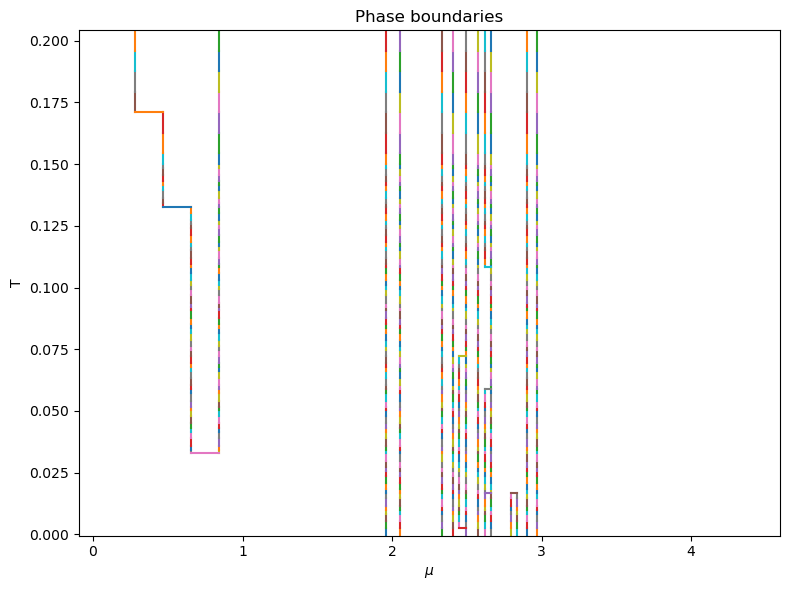

In [13]:
plot_phase_boundaries_from_grid(mu_vals, T_vals, Z)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def boundary_points_from_grid(mu_vals, T_vals, Z):
    mu_vals = np.asarray(mu_vals)
    T_vals = np.asarray(T_vals)
    Z = np.asarray(Z)

    nT, nmu = Z.shape
    pts = []

    # phase changes between neighboring mu cells
    for j in range(nT):
        for i in range(nmu - 1):
            z1 = Z[j, i]
            z2 = Z[j, i + 1]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                x = 0.5 * (mu_vals[i] + mu_vals[i + 1])
                y = T_vals[j]
                pts.append((x, y))

    # phase changes between neighboring T cells
    for j in range(nT - 1):
        for i in range(nmu):
            z1 = Z[j, i]
            z2 = Z[j + 1, i]
            if np.isnan(z1) or np.isnan(z2):
                continue
            if z1 != z2:
                x = mu_vals[i]
                y = 0.5 * (T_vals[j] + T_vals[j + 1])
                pts.append((x, y))

    if not pts:
        return np.empty((0, 2))

    pts = np.array(pts, dtype=float)
    pts = np.unique(np.round(pts, 12), axis=0)
    return pts


def connected_components_points(pts, x_tol, y_tol):
    n = len(pts)
    if n == 0:
        return []

    visited = np.zeros(n, dtype=bool)
    components = []

    for start in range(n):
        if visited[start]:
            continue

        stack = [start]
        visited[start] = True
        comp = []

        while stack:
            i = stack.pop()
            comp.append(i)

            dx = np.abs(pts[:, 0] - pts[i, 0])
            dy = np.abs(pts[:, 1] - pts[i, 1])

            neighbors = np.where((dx <= x_tol) & (dy <= y_tol))[0]
            for j in neighbors:
                if not visited[j]:
                    visited[j] = True
                    stack.append(j)

        components.append(pts[comp])

    return components


def sort_branch(branch):
    # choose the dominant spread direction
    dx = branch[:, 0].ptp()
    dy = branch[:, 1].ptp()

    if dx >= dy:
        return branch[np.argsort(branch[:, 0])]
    else:
        return branch[np.argsort(branch[:, 1])]


def plot_phase_boundaries_as_lines(mu_vals, T_vals, Z, linewidth=1.5, markersize=1):
    mu_vals = np.asarray(mu_vals)
    T_vals = np.asarray(T_vals)
    Z = np.asarray(Z)

    pts = boundary_points_from_grid(mu_vals, T_vals, Z)

    fig, ax = plt.subplots(figsize=(8, 6))

    # optional: show original grid points
    MU, TT = np.meshgrid(mu_vals, T_vals)
    # ax.plot(MU.ravel(), TT.ravel(), '.', color='lightgray', markersize=2)

    if len(pts) > 0:
        dmu = np.min(np.diff(np.unique(mu_vals))) if len(mu_vals) > 1 else 1.0
        dT  = np.min(np.diff(np.unique(T_vals))) if len(T_vals) > 1 else 1.0

        comps = connected_components_points(
            pts,
            x_tol=0.75 * dmu,
            y_tol=0.75 * dT
        )

        for comp in comps:
            if len(comp) == 1:
                ax.plot(comp[:, 0], comp[:, 1], 'o', color='black', markersize=markersize)
            else:
                comp = sort_branch(comp)
                ax.plot(
                    comp[:, 0], comp[:, 1],
                    '-o',
                    color='black',
                    linewidth=linewidth,
                    markersize=markersize
                )

    ax.set_xlabel(r'$\mu$')
    ax.set_ylabel(r'$T$')
    ax.set_title('Phase boundaries')
    plt.tight_layout()
    plt.show()

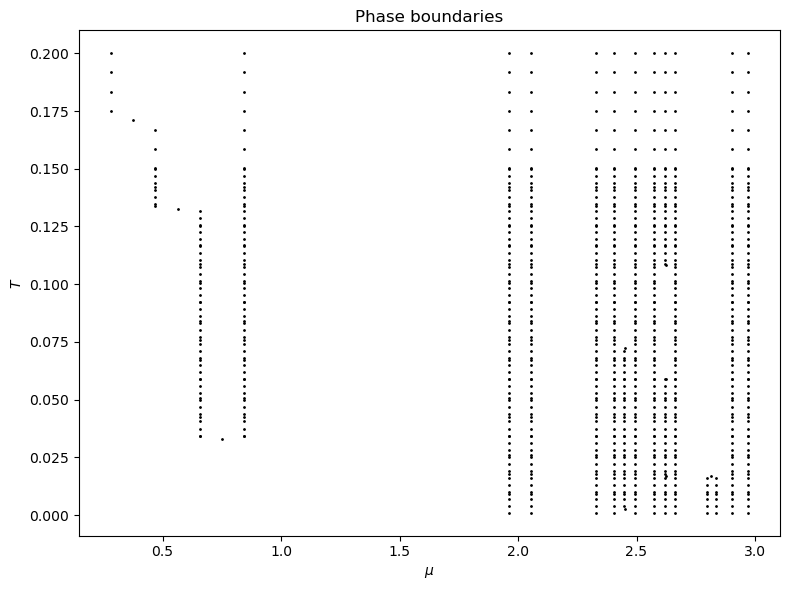

In [15]:
plot_phase_boundaries_as_lines(mu_vals, T_vals, Z)

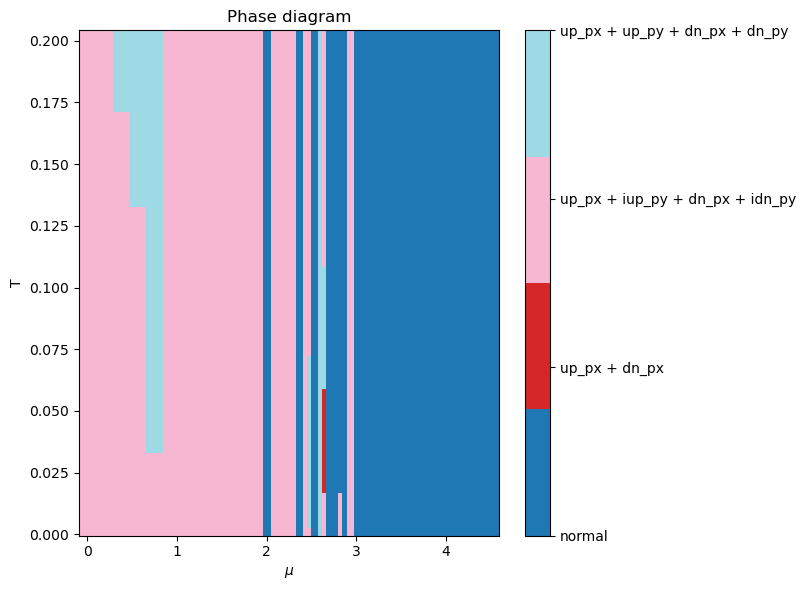

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, len(phase_order))))

plt.figure(figsize=(8, 6))
mesh = plt.pcolormesh(mu_vals, T_vals, Z, shading="nearest", cmap=cmap)

cbar = plt.colorbar(mesh, ticks=np.arange(len(phase_order)))
cbar.ax.set_yticklabels(phase_order)

plt.xlabel(r"$\mu$")
plt.ylabel("T")
plt.title("Phase diagram")
# plt.ylim(0.01,0.3)
plt.tight_layout()
plt.show()

In [17]:
from scipy.ndimage import zoom

# upsample for smooth appearance
Z_smooth = zoom(Z, 4, order=0)  # order=0 keeps phases discrete
mu_smooth = np.linspace(mu_vals.min(), mu_vals.max(), Z_smooth.shape[1])
T_smooth = np.linspace(T_vals.min(), T_vals.max(), Z_smooth.shape[0])

In [18]:

mu_arr = np.linspace(0.025, 1.5, 50)
T_arr = np.linspace(0.01, 0.8, 50)
print(T_arr)
print(mu_arr)

[0.01       0.02612245 0.0422449  0.05836735 0.0744898  0.09061224
 0.10673469 0.12285714 0.13897959 0.15510204 0.17122449 0.18734694
 0.20346939 0.21959184 0.23571429 0.25183673 0.26795918 0.28408163
 0.30020408 0.31632653 0.33244898 0.34857143 0.36469388 0.38081633
 0.39693878 0.41306122 0.42918367 0.44530612 0.46142857 0.47755102
 0.49367347 0.50979592 0.52591837 0.54204082 0.55816327 0.57428571
 0.59040816 0.60653061 0.62265306 0.63877551 0.65489796 0.67102041
 0.68714286 0.70326531 0.71938776 0.7355102  0.75163265 0.7677551
 0.78387755 0.8       ]
[0.025      0.05510204 0.08520408 0.11530612 0.14540816 0.1755102
 0.20561224 0.23571429 0.26581633 0.29591837 0.32602041 0.35612245
 0.38622449 0.41632653 0.44642857 0.47653061 0.50663265 0.53673469
 0.56683673 0.59693878 0.62704082 0.65714286 0.6872449  0.71734694
 0.74744898 0.77755102 0.80765306 0.8377551  0.86785714 0.89795918
 0.92806122 0.95816327 0.98826531 1.01836735 1.04846939 1.07857143
 1.10867347 1.13877551 1.16887755 1.1989